# Inflation ranking CIs (derived from PGDP)

Same procedure as `PGDP_CI`, but we rank forecasters on their **inflation** predictions, not on the price-level forecast directly.

Inflation at horizon $h$ is the annualized geometric quarterly rate implied by the forecaster's price-level path:
$$
\pi_h \;=\; 100 \cdot \!\left[\left(\frac{P_h}{P_{h-1}}\right)^{\!4} - 1\right]
$$
computed from `PGDP_{h-1}` and `PGDP_h` (with $P_1$ being the forecaster's lagged-quarter estimate). The realized side uses the advance vintage of each target quarter (same convention as `compute_errors`).

Inflation forecast error at $h$: $\hat\pi_h - \pi^{\text{real}}_h$ (in percentage points).

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from rankci import (
    rank_ci_stepwise_pairwise,
    rank_ci_marginal_pairwise,
    rank_confidence_intervals_simulation_pairwise,
    rank_ci_stepwise_simulation_pairwise,
    rank_ci_marginal_simulation_pairwise,
    compute_pairwise,
    load_spf,
    load_rtdsm,
    select_top_forecasters,
    winsorize_panel,
)
from rankci.data import (
    advance_vintage_col,
    get_advance_estimate,
    HORIZON_OFFSETS,
)

# Data Loading

In [21]:
df = load_spf("../data/Individual_PGDP.xlsx", sheet="PGDP")
print(f"SPF PGDP: {df.shape[0]} rows \u00d7 {df.shape[1]} columns")
df.head()

SPF PGDP: 9248 rows × 12 columns


/Users/Parimah/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,YEAR,QUARTER,ID,INDUSTRY,PGDP1,PGDP2,PGDP3,PGDP4,PGDP5,PGDP6,PGDPA,PGDPB
0,1968,4,1,NaN,122.0,123.0,124.0,125.0,125.0,126.0,NaN,NaN
1,1968,4,2,NaN,122.0,123.0,124.0,124.0,125.0,126.0,NaN,NaN
2,1968,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1968,4,4,NaN,122.0,123.0,124.0,125.0,126.0,127.0,NaN,NaN
4,1968,4,5,NaN,122.0,124.0,125.0,126.0,126.0,127.0,NaN,NaN


In [22]:
p_rtdsm = load_rtdsm("../data/PQvQd.xlsx", prefix="P", freq="quarterly")
print(f"RTDSM (P): {p_rtdsm.shape[0]} quarters \u00d7 {p_rtdsm.shape[1]} vintages")
p_rtdsm.head()

RTDSM (P): 317 quarters × 243 vintages


P65Q4    P66Q1    P66Q2    P66Q3    P66Q4    P67Q1    P67Q2  \
YEAR QUARTER                                                                  
1947 1        72.9765  72.9765  72.9765  72.9765  72.9765  72.9765  72.9765   
     2        73.6570  73.6570  73.6570  73.6570  73.6570  73.6570  73.6570   
     3        74.8708  74.8708  74.8708  74.8708  74.8708  74.8708  74.8708   
     4        76.9793  76.9793  76.9793  76.9793  76.9793  76.9793  76.9793   
1948 1        78.2088  78.2088  78.2088  78.2088  78.2088  78.2088  78.2088   

                P67Q3    P67Q4    P68Q1  ...   P24Q1   P24Q2   P24Q3   P24Q4  \
YEAR QUARTER                             ...                                   
1947 1        72.9765  72.9765  72.9765  ...  11.148  11.148  11.148  11.148   
     2        73.6570  73.6570  73.6570  ...  11.300  11.300  11.300  11.300   
     3        74.8708  74.8708  74.8708  ...  11.478  11.478  11.478  11.478   
     4        76.9793  76.9793  76.9793  ...  11.714  11.714  11.714  11.714   
1948 1        78.2088  78.2088  78.2088  ...  11.849  11.849  11.849  11.849   

               P25Q1   P25Q2   P25Q3   P25Q4   P26Q1   P26Q2  
YEAR QUARTER                                                  
1947 1        11.148  11.148  11.148  11.148  11.148  11.148  
     2        11.300  11.300  11.300  11.300  11.300  11.300  
     3        11.478  11.478  11.478  11.478  11.478  11.478  
     4        11.714  11.714  11.714  11.714  11.714  11.714  
1948 1        11.849  11.849  11.849  11.849  11.849  11.849  

[5 rows x 243 columns]

# Regime restriction (1996+)

The SPF `PGDP` target is not a single concept across the full history:

- **pre-1992**: implicit GNP deflator (fixed-weight)
- **1992 – 1995**: fixed-weight GDP deflator
- **1996+**: chain-weighted GDP price index

Mixing these regimes pools forecasters who were predicting *different objects*. The conservative fix is to restrict the sample to surveys submitted in 1996:Q1 or later, so every forecast is for the chain-weighted index. This costs ~28 years of early data but gives a homogeneous panel.

In [23]:
START_YEAR = 1996
n_before = len(df)
df = df[df["YEAR"] >= START_YEAR].reset_index(drop=True)
print(f"Restricted to surveys with YEAR >= {START_YEAR}: {n_before} → {len(df)} rows "
      f"({df['YEAR'].min()}:Q{df.loc[df['YEAR'].idxmin(), 'QUARTER']} "
      f"to {df['YEAR'].max()}:Q{df.loc[df['YEAR'].idxmax(), 'QUARTER']})")

Restricted to surveys with YEAR >= 1996: 9248 → 4800 rows (1996:Q1 to 2026:Q1)


# Deriving inflation from price levels

For each survey row at horizon $h \in \{2,\dots,6\}$:
- **Forecast inflation**: $\hat\pi_h = 100 \cdot ((\mathrm{PGDP}_h / \mathrm{PGDP}_{h-1})^4 - 1)$, computed within the survey (same base by construction).
- **Realized inflation** for target quarter $t = \text{survey} + \mathrm{offset}(h)$: take the advance vintage of $t$ (the column published right after $t$ is observed) and read **both** $P_t$ and $P_{t-1}$ from that single vintage column. Within one vintage the index is base-consistent, so BEA rebasings (e.g. 1985, 1991, 2009, 2013) don't contaminate the ratio.

In [24]:
def _annualized_inflation(p_cur, p_prev):
    """Annualized geometric quarterly inflation (%): 100 * ((p_cur / p_prev)^4 - 1)."""
    return 100.0 * ((p_cur / p_prev) ** 4 - 1.0)


def _prev_quarter(year, quarter):
    """Decrement a (year, quarter) tuple by one quarter (vectorized)."""
    total = (year - 1) * 4 + (quarter - 1) - 1
    y = ((total // 4) + 1).astype(int)
    q = ((total % 4) + 1).astype(int)
    return y, q


def realized_inflation_same_vintage(target_year, target_quarter, rtdsm):
    """
    Annualized realized inflation for target quarter t, using the advance
    vintage of t for BOTH P_t and P_{t-1}. Returns NaN if either lookup fails.
    """
    prefix = rtdsm.attrs.get("prefix", "P")
    col = advance_vintage_col(int(target_year), int(target_quarter), prefix)
    if col not in rtdsm.columns:
        return np.nan
    yp, qp = _prev_quarter(np.array([target_year]), np.array([target_quarter]))
    try:
        p_t = rtdsm.loc[(int(target_year), int(target_quarter)), col]
        p_p = rtdsm.loc[(int(yp[0]), int(qp[0])), col]
    except KeyError:
        return np.nan
    if pd.isna(p_t) or pd.isna(p_p) or p_p <= 0:
        return np.nan
    return _annualized_inflation(p_t, p_p)


def compute_inflation_errors(df, rtdsm, indicator="PGDP"):
    """
    Inflation forecast errors for horizons h ∈ {2..6}.

    Forecast: π̂_h = 100 * ((PGDP_h / PGDP_{h-1})^4 - 1).
    Realized: same formula on the advance vintage of t = survey + offset(h),
              reading both P_t and P_{t-1} from that single vintage column.
    """
    out = df[["YEAR", "QUARTER", "ID", "INDUSTRY"]].copy()
    for h in range(2, 7):
        if h not in HORIZON_OFFSETS or (h - 1) not in HORIZON_OFFSETS:
            continue

        offset_h = HORIZON_OFFSETS[h]
        total = (df["YEAR"] - 1) * 4 + (df["QUARTER"] - 1) + offset_h
        t_year = ((total // 4) + 1).astype(int)
        t_qtr  = ((total % 4) + 1).astype(int)

        realized = np.array([
            realized_inflation_same_vintage(y, q, rtdsm)
            for y, q in zip(t_year, t_qtr)
        ])
        forecast = _annualized_inflation(
            df[f"{indicator}{h}"].values,
            df[f"{indicator}{h - 1}"].values,
        )
        out[f"error_infl_{indicator}{h}"] = forecast - realized

    return out


def compute_inflation_error_panel(errors_df, indicator="PGDP", horizon=3, metric="squared"):
    """Pivot inflation errors at a chosen horizon to a wide (quarter × forecaster) panel."""
    err_col = f"error_infl_{indicator}{horizon}"
    panel = errors_df[["YEAR", "QUARTER", "ID", err_col]].copy()
    if metric == "squared":
        panel["value"] = panel[err_col] ** 2
    elif metric == "absolute":
        panel["value"] = panel[err_col].abs()
    else:
        raise ValueError(f"metric must be 'squared' or 'absolute', got {metric!r}")
    return panel.pivot_table(
        index=["YEAR", "QUARTER"], columns="ID", values="value",
    )

# Sanity check: realized inflation

Spot-check the derived realized inflation against known reference points.

In [25]:
header_pi = "π (% ann.)"
print(f"{'Target Quarter':<18} {'vintage':<10} {header_pi}")
print("-" * 50)
for y, q in [(1985, 4), (1995, 2), (2008, 4), (2020, 2), (2021, 4), (2022, 2)]:
    pi = realized_inflation_same_vintage(y, q, p_rtdsm)
    col = advance_vintage_col(y, q, "P")
    print(f"  {y}:Q{q:<13}  {col:<10} {pi:+.2f}")

Target Quarter     vintage    π (% ann.)
--------------------------------------------------
  1985:Q4              P86Q1      +3.49
  1995:Q2              P95Q3      +1.45
  2008:Q4              P09Q1      -0.07
  2020:Q2              P20Q3      -1.83
  2021:Q4              P22Q1      +6.94
  2022:Q2              P22Q3      +8.75


# Inflation forecast errors

In [26]:
errors_df = compute_inflation_errors(df, p_rtdsm, indicator="PGDP")

print("Inflation error summary by horizon (annualized % points):")
for h in range(2, 7):
    col = f"error_infl_PGDP{h}"
    if col in errors_df.columns:
        s = errors_df[col]
        print(f"  h={h}: mean={s.mean():+.2f}, std={s.std():.2f}, nan%={s.isna().mean()*100:.1f}%")

errors_df.head()

Inflation error summary by horizon (annualized % points):
  h=2: mean=-0.05, std=1.56, nan%=7.8%
  h=3: mean=-0.03, std=1.51, nan%=8.5%
  h=4: mean=-0.02, std=1.56, nan%=9.2%
  h=5: mean=-0.00, std=1.63, nan%=10.1%
  h=6: mean=+0.00, std=1.79, nan%=11.7%


,YEAR,QUARTER,ID,INDUSTRY,error_infl_PGDP2,error_infl_PGDP3,error_infl_PGDP4,error_infl_PGDP5,error_infl_PGDP6
0,1996,1,20,2.0,-0.389744,-1.489491,1.475769,-1.103947,-1.653452
1,1996,1,40,2.0,0.373585,0.737205,1.098242,1.086928,0.155180
2,1996,1,65,1.0,-0.375329,-0.374261,0.741981,0.366432,NaN
3,1996,1,84,1.0,0.004859,0.373577,0.739607,1.473690,NaN
4,1996,1,94,1.0,1.139189,-0.377661,-0.003370,0.366432,-0.556205


In [27]:
# Squared inflation-error panel for h=3 (one-quarter-ahead inflation)
HORIZON = 3
X_wide = compute_inflation_error_panel(
    errors_df, indicator="PGDP", horizon=HORIZON, metric="squared",
)
print(f"Panel shape: {X_wide.shape[0]} quarters \u00d7 {X_wide.shape[1]} forecasters")
X_wide.head()

Panel shape: 118 quarters × 153 forecasters


ID                 20        40        65        84        94        99   \
YEAR QUARTER                                                               
1996 1        2.218585  0.543471  0.140071  0.139560  0.142628       NaN   
     2             NaN       NaN  0.135760  0.543520       NaN  0.132794   
     3        1.211457       NaN  0.000011  0.547937       NaN       NaN   
     4             NaN       NaN  1.636975  0.306877       NaN  0.034901   
1997 1        3.511900       NaN  0.002528  1.281512       NaN       NaN   

ID                 404       405       407       409  ...  599  600  601  602  \
YEAR QUARTER                                          ...                       
1996 1        0.080075       NaN  0.077996  0.144015  ...  NaN  NaN  NaN  NaN   
     2        0.134272  0.540038  0.925895       NaN  ...  NaN  NaN  NaN  NaN   
     3        0.541001  0.541001  4.903935       NaN  ...  NaN  NaN  NaN  NaN   
     4        0.033183       NaN  0.848856       NaN  ...  NaN  NaN  NaN  NaN   
1997 1        0.002027       NaN  6.732851       NaN  ...  NaN  NaN  NaN  NaN   

ID            603  605  606  607  608  609  
YEAR QUARTER                                
1996 1        NaN  NaN  NaN  NaN  NaN  NaN  
     2        NaN  NaN  NaN  NaN  NaN  NaN  
     3        NaN  NaN  NaN  NaN  NaN  NaN  
     4        NaN  NaN  NaN  NaN  NaN  NaN  
1997 1        NaN  NaN  NaN  NaN  NaN  NaN  

[5 rows x 153 columns]

# Forecaster Selection

In [28]:
obs_counts = X_wide.notna().sum()
mean_mse = X_wide.mean()

stats = pd.DataFrame({
    "obs_count": obs_counts,
    "mean_mse":  mean_mse,
    "rmse":      np.sqrt(mean_mse),
}).sort_values("obs_count", ascending=False)

print(f"Total forecasters: {len(stats)}")
print(f"Forecasters with >= 20 obs: {(stats['obs_count'] >= 20).sum()}")
print(f"Forecasters with >= 50 obs: {(stats['obs_count'] >= 50).sum()}")
stats.head(20)

Total forecasters: 153
Forecasters with >= 20 obs: 70
Forecasters with >= 50 obs: 38


,obs_count,mean_mse,rmse
ID,,,
510,104,2.073477,1.439957
426,102,2.003437,1.415428
463,101,2.159565,1.469546
484,100,2.186939,1.478830
428,100,2.209691,1.486503
433,98,2.483139,1.575798
411,98,2.269811,1.506589
421,97,2.165130,1.471438
504,95,5.596714,2.365737


In [29]:
N = 8
X_panel = select_top_forecasters(X_wide, N=N, min_obs=20)
print(f"Selected {X_panel.shape[1]} forecasters, {X_panel.shape[0]} quarters")
print(f"Forecaster IDs: {X_panel.columns.tolist()}")

Selected 8 forecasters, 118 quarters
Forecaster IDs: [510, 426, 463, 428, 484, 411, 433, 421]


# Rank Confidence Intervals

In [30]:
X = X_panel.values
population_ids = X_panel.columns.tolist()

out = rank_ci_stepwise_pairwise(X, alpha=0.05, B=5000, seed=42)

results = pd.DataFrame({
    "ID":         population_ids,
    "MSE":        out["theta_hat"].round(4),
    "RMSE":       np.sqrt(out["theta_hat"]).round(4),
    "CI_lower":   out["rank_ci"][:, 0],
    "CI_upper":   out["rank_ci"][:, 1],
}).sort_values("MSE")
results.index = range(1, len(results) + 1)
results.index.name = "Rank"
results

=== Pairwise shared observations ===
  Min: 80, Mean: 84.6, Max: 89
  Pairs with < 20 shared obs: 0

=== Test statistics (delta_hat / se) ===
  Max: 1.9731, Pairs with t > 1.96: 1


,ID,MSE,RMSE,CI_lower,CI_upper
Rank,,,,,
1,426,2.0034,1.4154,1,8
2,510,2.0735,1.4400,1,8
3,463,2.1596,1.4695,1,8
4,421,2.1651,1.4714,1,8
5,484,2.1869,1.4788,1,8
6,428,2.2097,1.4865,1,8
7,411,2.2698,1.5066,1,8
8,433,2.4831,1.5758,1,8


# Worst-Quarter Inspection

Time coverage: (1996, 1) to (2025, 4) (118 quarters)

Top 10 quarters with highest avg squared inflation-forecast error:
YEAR  QUARTER
2022  1          25.883415
2021  4          24.667718
      1          18.706426
      3          16.020663
2020  1          13.440240
2021  2           8.319168
2020  2           8.162082
2008  3           6.622047
2001  3           6.465324
2020  4           6.009524
dtype: float64


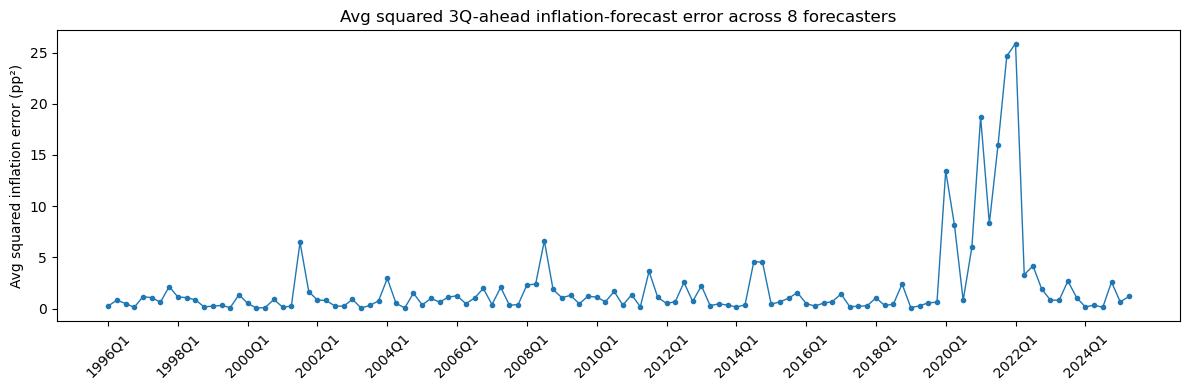

In [31]:
period_mse = X_panel.mean(axis=1)

print(f"Time coverage: {X_panel.index[0]} to {X_panel.index[-1]} ({len(X_panel)} quarters)\n")
print("Top 10 quarters with highest avg squared inflation-forecast error:")
print(period_mse.nlargest(10))

n = len(X_panel)
plt.figure(figsize=(12, 4))
plt.plot(range(n), period_mse, marker="o", linewidth=1, markersize=3)
plt.xticks(
    ticks=range(0, n, 8),
    labels=[f"{y}Q{q}" for y, q in X_panel.index[::8]],
    rotation=45,
)
plt.ylabel("Avg squared inflation error (pp\u00b2)")
plt.title(f"Avg squared {HORIZON}Q-ahead inflation-forecast error across {N} forecasters")
plt.tight_layout()
plt.show()

# Winsorization (pairwise differences)

In [32]:
print("=== Winsorize pairwise differences ===")
print(f"{'winsor_pct':<12} {'max_t':<10} {'mean CI width':<16}")
print("-" * 40)
for winsor_pct in [99, 97, 95, 90]:
    delta_w, se_w, _ = compute_pairwise(X, se_method="nw", winsor_pct=winsor_pct)
    t_vals = (delta_w / se_w)[~np.isnan(se_w)]

    out_w = rank_ci_stepwise_pairwise(
        X, alpha=0.05, B=1000, seed=42, winsor_pct=winsor_pct, verbose=False,
    )
    widths = out_w["rank_ci"][:, 1] - out_w["rank_ci"][:, 0]
    print(f"  {winsor_pct:<10} {t_vals.max():<10.3f} {widths.mean():<16.2f}")

=== Winsorize pairwise differences ===
winsor_pct   max_t      mean CI width   
----------------------------------------
  99         2.256      7.00            
  97         2.717      7.00            
  95         2.982      7.00            
  90         3.234      7.00            


# Marginal Rank Confidence Intervals

In [33]:
out_marg = rank_ci_marginal_pairwise(X, alpha=0.1, B=5000, seed=42)

results_marg = pd.DataFrame({
    "ID":       population_ids,
    "MSE":      out_marg["theta_hat"].round(4),
    "RMSE":     np.sqrt(out_marg["theta_hat"]).round(4),
    "cv_j":     out_marg["critical_values"].round(3),
    "CI_lower": out_marg["rank_ci"][:, 0],
    "CI_upper": out_marg["rank_ci"][:, 1],
}).sort_values("MSE")
results_marg.index = range(1, len(results_marg) + 1)
results_marg.index.name = "Rank"
results_marg

,ID,MSE,RMSE,cv_j,CI_lower,CI_upper
Rank,,,,,,
1,426,2.0034,1.4154,1.977,1,8
2,510,2.0735,1.4400,2.775,1,8
3,463,2.1596,1.4695,3.206,1,8
4,421,2.1651,1.4714,2.714,1,8
5,484,2.1869,1.4788,2.112,1,8
6,428,2.2097,1.4865,3.340,1,8
7,411,2.2698,1.5066,2.487,1,8
8,433,2.4831,1.5758,2.294,1,8


# Sensitivity to NW bandwidth `L`

In [34]:
L_values = [None, 1, 2, 4, 8, 20]
ci_by_L = {}
maxt_by_L = {}
for L in L_values:
    delta, se, _ = compute_pairwise(X, se_method="nw", L=L)
    maxt_by_L[L] = float(np.nanmax(delta / se))
    out_L = rank_ci_marginal_pairwise(X, alpha=0.05, B=2000, seed=42, L=L)
    ci_by_L[L] = out_L["rank_ci"]

order = np.argsort(out_marg["theta_hat"])
ordered_ids = [population_ids[i] for i in order]

table_L = pd.DataFrame(
    {
        f"L={L if L is not None else 'auto'}":
            [f"[{ci_by_L[L][i, 0]},{ci_by_L[L][i, 1]}]" for i in order]
        for L in L_values
    },
    index=ordered_ids,
)
table_L.index.name = "ID"

print("max test stat by L:")
for L, t in maxt_by_L.items():
    label = "auto" if L is None else str(L)
    print(f"  L={label:<5}  max_t = {t:.3f}")
print()
table_L

max test stat by L:
  L=auto   max_t = 1.973
  L=1      max_t = 1.855
  L=2      max_t = 1.882
  L=4      max_t = 2.059
  L=8      max_t = 2.027
  L=20     max_t = 1.997



,L=auto,L=1,L=2,L=4,L=8,L=20
ID,,,,,,
426,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
510,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
463,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
421,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
484,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
428,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
411,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
433,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"


# MAE-based ranking

In [35]:
N      = 5
alpha  = 0.2
L      = None

X_mae_wide  = compute_inflation_error_panel(errors_df, indicator="PGDP", horizon=HORIZON, metric="absolute")
X_mae_panel = select_top_forecasters(X_mae_wide, N=N, min_obs=20)
X_mae       = X_mae_panel.values
ids_mae     = X_mae_panel.columns.tolist()

out_mae = rank_ci_marginal_pairwise(X_mae, alpha=alpha, B=5000, seed=42, L=L)

X_mse_wide  = compute_inflation_error_panel(errors_df, indicator="PGDP", horizon=HORIZON, metric="squared")
X_mse_panel = select_top_forecasters(X_mse_wide, N=N, min_obs=20)
X_mse       = X_mse_panel.values
ids_mse     = X_mse_panel.columns.tolist()

out_mse = rank_ci_marginal_pairwise(X_mse, alpha=alpha, B=5000, seed=42, L=L)

order = np.argsort(out_mae["theta_hat"])

results_compare = pd.DataFrame({
    "ID":       [ids_mae[i] for i in order],
    "MAE":      out_mae["theta_hat"][order].round(3),
    "MSE":      out_mse["theta_hat"][order].round(4),
    "CI_MAE":   [f"[{l},{u}]" for l, u in out_mae["rank_ci"][order]],
    "CI_MSE":   [f"[{l},{u}]" for l, u in out_mse["rank_ci"][order]],
})
results_compare.index = range(1, len(results_compare) + 1)
results_compare.index.name = "MAE_rank"
results_compare

,ID,MAE,MSE,CI_MAE,CI_MSE
MAE_rank,,,,,
1,510,0.997,2.0735,"[1,5]","[1,5]"
2,463,1.004,2.1596,"[1,5]","[1,5]"
3,428,1.052,2.2097,"[1,5]","[1,5]"
4,484,1.068,2.1869,"[1,5]","[1,5]"
5,426,1.101,2.0034,"[1,5]","[1,5]"
